# Square Labeling from Bounding Box Annotations

## ⚠️ DEPRECATED NOTEBOOK ⚠️

**This notebook is DEPRECATED when using UNet-based geometry and is kept for comparison/experimental purposes only.**

**Status:** This notebook uses YOLO bounding boxes for square labeling, which has been replaced by the classifier-based approach in the new pipeline.

**Recommended Pipeline:**
- **03_unet_training.ipynb** → Train UNet for board segmentation
- **04b_batch_warp_from_unet.ipynb** → Batch warp using UNet (PRODUCTION)
- **05_square_extraction.ipynb** → Extract 64 squares from warped boards
- **06_piece_classifier_training.ipynb** → Train piece classifier (NEW)
- **07_square_inference_to_labels.ipynb** → Label squares using classifier (NEW)

**Original Goal:** Assign piece class labels to every square crop using YOLO bounding box annotations and homography matrices.

**Original Pipeline:**
1. Load square crops + metadata from notebook 05
2. Load homography matrices from notebook 04
3. Load piece bounding boxes from YOLO labels (Chess Pieces.yolov8-obb)
4. Warp bbox centers to board space and assign to squares
5. Generate square_labels.csv and label_map.json
6. Create debug visualizations

In [ ]:
# Standard imports
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from collections import defaultdict, Counter
import random
import warnings
warnings.filterwarnings('ignore')

# Set up paths
possible_roots = [
    Path.cwd().parent,  # If running from notebooks/ directory
    Path.cwd(),         # If running from workspace root
]

PROJECT_ROOT = None
for root in possible_roots:
    test_path = root / "data" / "processed" / "squares_boardcoords"
    if test_path.exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

# Input paths
SQUARES_BASE = PROJECT_ROOT / "data" / "processed" / "squares_boardcoords"
WARPED_BASE = PROJECT_ROOT / "data" / "processed" / "warped_boardcoords"
CHESS_PIECES_BASE = PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces"

# Output paths
OUTPUT_BASE = SQUARES_BASE

# Constants
BOARD_SIZE = 800
SQUARE_SIZE = 100
GRID_SIZE = 8

print(f"Project root: {PROJECT_ROOT}")
print(f"Squares base: {SQUARES_BASE}")
print(f"Warped base: {WARPED_BASE}")
print(f"Chess pieces base: {CHESS_PIECES_BASE}")
print(f"\nBoard size: {BOARD_SIZE}x{BOARD_SIZE}")
print(f"Square size: {SQUARE_SIZE}x{SQUARE_SIZE}")
print(f"Grid size: {GRID_SIZE}x{GRID_SIZE}")

Project root: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision
Squares base: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/squares_boardcoords
Warped base: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/processed/warped_boardcoords
Chess pieces base: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Chess_pieces

Board size: 800x800
Square size: 100x100
Grid size: 8x8


## A) Filename Matching Functions

In [ ]:
# Try to import shapely for polygon operations, fallback to cv2-based implementation
# Note: shapely is optional - cv2-based fallback works correctly
try:
    from shapely.geometry import Polygon, box
    SHAPELY_AVAILABLE = True
except ImportError:
    SHAPELY_AVAILABLE = False
    # cv2-based fallback is used automatically - no action needed

def compute_polygon_area(points):
    """Compute area of polygon using shoelace formula."""
    if len(points) < 3:
        return 0.0
    points = np.array(points, dtype=np.float32)
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def polygon_rect_intersection_area(polygon_points, rect_xmin, rect_ymin, rect_xmax, rect_ymax):
    """
    Compute intersection area between polygon and rectangle.
    Uses shapely if available, otherwise cv2-based mask intersection.
    """
    if SHAPELY_AVAILABLE:
        try:
            poly = Polygon(polygon_points)
            rect = box(rect_xmin, rect_ymin, rect_xmax, rect_ymax)
            intersection = poly.intersection(rect)
            return intersection.area
        except:
            # Fallback to cv2 if shapely fails
            pass

    # Use cv2 for polygon-rectangle clipping via mask intersection
    # Clip coordinates to valid range
    rect_xmin = max(0, int(rect_xmin))
    rect_ymin = max(0, int(rect_ymin))
    rect_xmax = min(BOARD_SIZE, int(rect_xmax))
    rect_ymax = min(BOARD_SIZE, int(rect_ymax))

    if rect_xmax <= rect_xmin or rect_ymax <= rect_ymin:
        return 0.0

    # Create mask for rectangle
    mask = np.zeros((BOARD_SIZE, BOARD_SIZE), dtype=np.uint8)
    rect_points = np.array([
        [rect_xmin, rect_ymin],
        [rect_xmax, rect_ymin],
        [rect_xmax, rect_ymax],
        [rect_xmin, rect_ymax]
    ], dtype=np.int32)
    cv2.fillPoly(mask, [rect_points], 255)

    # Create mask for polygon (clip to board bounds)
    poly_points = np.array(polygon_points, dtype=np.float32)
    poly_points[:, 0] = np.clip(poly_points[:, 0], 0, BOARD_SIZE - 1)
    poly_points[:, 1] = np.clip(poly_points[:, 1], 0, BOARD_SIZE - 1)
    poly_points_int = poly_points.astype(np.int32)

    poly_mask = np.zeros((BOARD_SIZE, BOARD_SIZE), dtype=np.uint8)
    cv2.fillPoly(poly_mask, [poly_points_int], 255)

    # Intersection
    intersection_mask = cv2.bitwise_and(mask, poly_mask)
    return np.sum(intersection_mask > 0).astype(float)

def stem_no_ext(name):
    """
    Extract stem without extension ONLY. Keeps full stem including '_jpg.rf.<hash>' part.
    Example: "00bc..._jpg.rf.1a14..." -> "00bc..._jpg.rf.1a14..." (no change if already stem)
    Example: "00bc..._jpg.rf.1a14.txt" -> "00bc..._jpg.rf.1a14"
    """
    s = str(name)
    s = s.split('/')[-1]  # Get filename from path
    s = s.rsplit('.', 1)[0]  # Remove extension only
    return s

def base_hash(name):
    """
    Extract base hash (before '_jpg.rf' or '.rf').
    Example: "00bc..._jpg.rf.1a14..." -> "00bc..."
    This is for reference only - do NOT use for matching squares ↔ yolo.
    """
    s = str(name)
    s = s.split('/')[-1]  # Get filename from path
    s = s.rsplit('.', 1)[0]  # Remove extension
    if "_jpg.rf." in s:
        return s.split("_jpg.rf.")[0]
    if ".rf." in s:
        return s.split(".rf.")[0]
    if "_jpg" in s:
        return s.split("_jpg")[0]
    return s

# Keep normalize_filename for backward compatibility but deprecate it
def normalize_filename(s):
    """DEPRECATED: Use stem_no_ext() for matching instead."""
    return stem_no_ext(s)

def row_col_to_chess_notation(row, col):
    """Convert grid position (row, col) to chess notation (a1-h8)."""
    file_letter = chr(ord('a') + col)
    rank_number = 8 - row
    return f"{file_letter}{rank_number}"

print("✓ Helper functions loaded")

✓ Helper functions loaded


## B) Load and Match YOLO Annotations

## B.0) Find Correct Annotation Source

In [ ]:
# Find which annotation source matches Board_coordinates images
print("="*80)
print("FINDING CORRECT ANNOTATION SOURCE")
print("="*80)

# Get 5 random Board_coordinates train images
board_coords_dir = PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Board_coordinates" / "train" / "images"
board_files = sorted(list(board_coords_dir.glob("*.jpg")))[:5]

print("\n5 Board_coordinates train images:")
for f in board_files:
    stem = f.stem
    norm = normalize_filename(stem)
    print(f"  {f.name}")
    print(f"    -> stem: {stem}")
    print(f"    -> normalized: {norm}")

# Candidate annotation sources
candidates = {
    'CSV_Chess_pieces_train': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces" / "train" / "_annotations.csv",
    'CSV_Chess_pieces_valid': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces" / "valid" / "_annotations.csv",
    'CSV_Chess_pieces_test': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces" / "test" / "_annotations.csv",
    'YOLO_yolov8_obb_train': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess Pieces.yolov8-obb" / "train" / "labels",
    'YOLO_yolov8_obb_valid': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess Pieces.yolov8-obb" / "valid" / "labels",
    'YOLO_yolov8_obb_test': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess Pieces.yolov8-obb" / "test" / "labels",
    'YOLO_Chess_pieces_train': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces" / "train" / "labels",
    'YOLO_Chess_pieces_valid': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces" / "valid" / "labels",
    'YOLO_Chess_pieces_test': PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess_pieces" / "test" / "labels",
}

print("\n" + "="*80)
print("SCANNING CANDIDATE ANNOTATION SOURCES")
print("="*80)

matches_found = {}
board_stems = [f.stem for f in board_files]
board_norms = {normalize_filename(s) for s in board_stems}

for source_name, source_path in candidates.items():
    if not source_path.exists():
        continue

    matches = 0

    if source_name.startswith('CSV_'):
        # Check CSV file
        try:
            df = pd.read_csv(source_path)
            if 'filename' in df.columns:
                csv_norms = {normalize_filename(fn) for fn in df['filename'].unique()}
                matches = len(board_norms.intersection(csv_norms))
        except:
            pass

    elif source_name.startswith('YOLO_'):
        # Check YOLO labels directory
        label_files = list(source_path.glob("*.txt"))
        yolo_norms = {normalize_filename(f.stem) for f in label_files}
        matches = len(board_norms.intersection(yolo_norms))

    if matches > 0:
        matches_found[source_name] = {
            'path': source_path,
            'matches': matches,
            'total': len(board_stems)
        }
        print(f"\n✓ {source_name}:")
        print(f"  Path: {source_path}")
        print(f"  Matches: {matches}/{len(board_stems)}")

if len(matches_found) == 0:
    print("\n❌ NO MATCHES FOUND in any annotation source!")
else:
    print("\n" + "="*80)
    print("CONCLUSION")
    print("="*80)
    best_source = max(matches_found.items(), key=lambda x: x[1]['matches'])
    print(f"\n✓ Best matching source: {best_source[0]}")
    print(f"  Matches: {best_source[1]['matches']}/{best_source[1]['total']}")
    print(f"  Path: {best_source[1]['path']}")

    if best_source[0].startswith('YOLO_'):
        print(f"\n  → Using YOLO format labels (.txt files)")
    else:
        print(f"\n  → Using CSV format annotations")

print("="*80)

FINDING CORRECT ANNOTATION SOURCE

5 Board_coordinates train images:
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3.jpg
    -> stem: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3
    -> normalized: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.20e061b75dc554ebe40b33189e320831.jpg
    -> stem: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.20e061b75dc554ebe40b33189e320831
    -> normalized: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.38c0bb7971151bf4cb185f5498fddcc0.jpg
    -> stem: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.38c0bb7971151bf4cb185f5498fddcc0
    -> normalized: 00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf
  0115e4df73475b550e5c6f7a88b2474f_jpg.rf.22f030d1bd7a26c987f287d2de4b19c7.jpg
    -> stem: 0115e4df73475b550e5c6f7a88b2474f_jpg.rf.22f030d1bd7a26c987f287d2de4b19c7
    -> normalized: 0115e4df73475b550e5c6f7a88b2474f_jpg.rf
  0115e4df73475b550e5c6f7a88b2474f_

In [ ]:
# Use YOLO labels from Chess Pieces.yolov8-obb (matches Board_coordinates images)
YOLO_BASE = PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Chess Pieces.yolov8-obb"

# Split mapping: Board_coordinates uses {train, validation, test}
# YOLO uses {train, valid, test}
SPLIT_MAPPING = {
    'train': 'train',
    'validation': 'valid',  # Map validation -> valid
    'test': 'test'
}

# Load YOLO class names from data.yaml
yolo_class_map = {}
yolo_data_yaml = YOLO_BASE / "data.yaml"
if yolo_data_yaml.exists():
    try:
        import yaml
        with open(yolo_data_yaml, 'r') as f:
            yolo_data_yaml_content = yaml.safe_load(f)
            if 'names' in yolo_data_yaml_content:
                yolo_class_map = {int(k): v for k, v in yolo_data_yaml_content['names'].items()}
                print(f"Loaded YOLO class map: {len(yolo_class_map)} classes")
                for class_id, class_name in sorted(yolo_class_map.items()):
                    print(f"  {class_id}: {class_name}")
    except ImportError:
        print("⚠️ yaml module not found, using default class mapping")
        # Fallback: use class IDs as names
        yolo_class_map = {i: f"class_{i}" for i in range(13)}

# Load YOLO annotations for each split
yolo_data = {}
yolo_stats = {}

def parse_yolo_label(label_path, img_width=640, img_height=640):
    """
    Parse YOLO label file.
    Format: class_id x_center y_center width height (all normalized 0-1)
    Returns: list of dicts with 'class_id', 'class', 'xmin', 'ymin', 'xmax', 'ymax' (absolute)
    """
    bboxes = []
    if not label_path.exists():
        return bboxes

    try:
        with open(label_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center_norm = float(parts[1])
                    y_center_norm = float(parts[2])
                    width_norm = float(parts[3])
                    height_norm = float(parts[4])

                    # Convert to absolute coordinates
                    x_center = x_center_norm * img_width
                    y_center = y_center_norm * img_height
                    width = width_norm * img_width
                    height = height_norm * img_height

                    # Convert to xmin, ymin, xmax, ymax
                    xmin = x_center - width / 2
                    ymin = y_center - height / 2
                    xmax = x_center + width / 2
                    ymax = y_center + height / 2

                    class_name = yolo_class_map.get(class_id, f"class_{class_id}")

                    bboxes.append({
                        'class_id': class_id,
                        'class': class_name,
                        'x_center': x_center,
                        'y_center': y_center,
                        'xmin': xmin,
                        'ymin': ymin,
                        'xmax': xmax,
                        'ymax': ymax,
                        'width': width,
                        'height': height,
                        'yolo_img_width': img_width,  # Store YOLO image dimensions for scaling
                        'yolo_img_height': img_height
                    })
    except Exception as e:
        print(f"  ⚠️ Error parsing {label_path}: {e}")

    return bboxes

for board_split, yolo_split in SPLIT_MAPPING.items():
    yolo_labels_dir = YOLO_BASE / yolo_split / "labels"
    yolo_images_dir = YOLO_BASE / yolo_split / "images"

    if not yolo_labels_dir.exists():
        print(f"⚠️ YOLO labels dir not found: {yolo_labels_dir}")
        yolo_data[board_split] = None
        continue

    print(f"\nLoading YOLO labels: {yolo_labels_dir}")
    label_files = sorted(list(yolo_labels_dir.glob("*.txt")))
    print(f"  Total label files: {len(label_files)}")

    # Build dict: exact_stem -> list of bbox dicts (no normalization)
    bboxes_by_stem = {}
    total_bboxes = 0
    classes_found = set()

    # Get all image files for exact matching
    image_files = {}
    if yolo_images_dir.exists():
        for img_file in yolo_images_dir.glob("*.jpg"):
            image_files[img_file.stem] = img_file

    # Process each label file with EXACT stem matching (no normalization)
    for label_file in label_files:
        stem = label_file.stem  # Use exact stem (filename without extension)
        # This stem includes full hash: "00bc..._jpg.rf.1a1407..." (no .txt)

        # Find corresponding image file (should have same stem)
        if stem not in image_files:
            continue  # Skip if no matching image

        img_file = image_files[stem]

        # Get image dimensions for this specific image
        img_width, img_height = 416, 416  # Default
        try:
            img = cv2.imread(str(img_file))
            if img is not None:
                h, w = img.shape[:2]
                img_width, img_height = w, h
        except:
            pass

        # Parse YOLO label with correct dimensions
        bboxes = parse_yolo_label(label_file, img_width, img_height)

        if len(bboxes) > 0:
            bboxes_by_stem[stem] = bboxes  # Use EXACT stem as key (includes full hash)
            total_bboxes += len(bboxes)
            for bbox in bboxes:
                classes_found.add(bbox['class'])

    unique_files = len(bboxes_by_stem)
    print(f"  Unique files (exact stems): {unique_files}")
    print(f"  Total bboxes: {total_bboxes}")
    print(f"  Classes: {sorted(classes_found)}")

    yolo_data[board_split] = bboxes_by_stem

    # Stats
    yolo_stats[board_split] = {
        'total_bboxes': total_bboxes,
        'unique_files': unique_files,
        'classes': sorted(classes_found)
    }

print("\n" + "="*80)
print("YOLO LABELS LOADING SUMMARY")
print("="*80)
for split, stats in yolo_stats.items():
    if stats:
        print(f"\n{split.upper()}:")
        print(f"  Total bboxes: {stats['total_bboxes']}")
        print(f"  Unique files: {stats['unique_files']}")
        print(f"  Classes: {', '.join(stats['classes'])}")

Loaded YOLO class map: 13 classes
  0: bishop
  1: black-bishop
  2: black-king
  3: black-knight
  4: black-pawn
  5: black-queen
  6: black-rook
  7: white-bishop
  8: white-king
  9: white-knight
  10: white-pawn
  11: white-queen
  12: white-rook

Loading YOLO labels: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Chess Pieces.yolov8-obb/train/labels
  Total label files: 606
  Unique files (exact stems): 606
  Total bboxes: 6324
  Classes: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']

Loading YOLO labels: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Chess Pieces.yolov8-obb/valid/

## B.5) Quick Check: Filename Matching Verification

In [ ]:
# Quick check: Print examples and verify at least 1 match
print("="*80)
print("FILENAME MATCHING QUICK CHECK")
print("="*80)

# Get board stems from train split metadata
train_metadata_path = SQUARES_BASE / "train" / "squares_metadata.csv"
if train_metadata_path.exists():
    train_df = pd.read_csv(train_metadata_path)
    board_stems = train_df['board_stem'].unique()

    print("\nBoard stems (EXACT - no normalization):")
    for stem in list(board_stems)[:5]:
        print(f"  {stem}")

    # Get YOLO stems (keys are exact stems - already no extension)
    train_yolo_dict = yolo_data.get('train')
    if train_yolo_dict:
        yolo_keys = list(train_yolo_dict.keys())[:5]
        print("\nYOLO keys (EXACT - no normalization):")
        for key in yolo_keys:
            print(f"  {key}")

        # Check for matches using EXACT stems (no normalization on either side)
        board_set = set(board_stems)
        yolo_set = set(train_yolo_dict.keys())
        matches = board_set.intersection(yolo_set)

        print(f"\nMatches found: {len(matches)}")
        if matches:
            match_list = list(matches)[:3]
            print("  Example matches:")
            for match in match_list:
                print(f"    {match}")
            assert len(matches) > 0, "At least 1 match required!"
            print("✓ PASS: At least 1 match found")
        else:
            print("✗ FAIL: No matches found")
            print("  First 3 board stems:", list(board_stems)[:3])
            print("  First 3 YOLO keys:", yolo_keys[:3])
            assert False, "No matches found! Check stem matching logic."
    else:
        print("⚠️ No YOLO data for train split")
else:
    print("⚠️ Train metadata not found")

print("="*80)

FILENAME MATCHING QUICK CHECK

Board stems (EXACT - no normalization):
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.20e061b75dc554ebe40b33189e320831
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.38c0bb7971151bf4cb185f5498fddcc0
  0115e4df73475b550e5c6f7a88b2474f_jpg.rf.22f030d1bd7a26c987f287d2de4b19c7
  0115e4df73475b550e5c6f7a88b2474f_jpg.rf.254cb905329fee7e2df63d14b15368db

YOLO keys (EXACT - no normalization):
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.20e061b75dc554ebe40b33189e320831
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.38c0bb7971151bf4cb185f5498fddcc0
  0115e4df73475b550e5c6f7a88b2474f_jpg.rf.22f030d1bd7a26c987f287d2de4b19c7
  0115e4df73475b550e5c6f7a88b2474f_jpg.rf.254cb905329fee7e2df63d14b15368db

Matches found: 129
  Example matches:
    22e74efb18b2d88fba63d25a61bf5f97_jpg.rf.e472c82b49f6f6da28b302bda8ecc4d4
    5a8433ec79c881f84ef1

## C) Main Labeling Function

In [ ]:
def process_split_labeling(split_name, debug_n=3):
    """
    Process one split: assign labels to all squares.

    Returns:
        square_labels_df: DataFrame with square labels
        stats: Dictionary with statistics
    """
    print(f"\n{'='*80}")
    print(f"Processing {split_name.upper()} split")
    print(f"{'='*80}")

    # Set up paths
    squares_metadata_path = SQUARES_BASE / split_name / "squares_metadata.csv"
    warped_images_dir = WARPED_BASE / split_name / "images"
    # Get path to original Board_coordinates images (for getting original dimensions)
    board_coords_base = PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Board_coordinates"
    board_coords_images_dir = board_coords_base / split_name / "images"
    debug_output_dir = PROJECT_ROOT / "data" / "processed" / "labels_boardcoords" / split_name / "debug"
    debug_output_dir.mkdir(parents=True, exist_ok=True)

    # Load square metadata
    if not squares_metadata_path.exists():
        print(f"⚠️ Metadata not found: {squares_metadata_path}")
        return None, None

    squares_df = pd.read_csv(squares_metadata_path)
    print(f"Loaded {len(squares_df)} square records")

    # Get YOLO data for this split (dict: exact_stem -> list of bbox dicts)
    yolo_split = SPLIT_MAPPING[split_name]
    bboxes_by_stem = yolo_data.get(split_name)

    if bboxes_by_stem is None:
        print(f"⚠️ No YOLO data available for {split_name}")
        return None, None

    # Get unique board stems
    unique_boards = squares_df['board_stem'].unique()
    print(f"Unique boards: {len(unique_boards)}")

    # Match boards to YOLO labels using EXACT stems (no normalization)
    # board_stem from CSV is already a stem (no extension), yolo keys are also exact stems
    matched_boards = set()
    board_to_bboxes = {}

    # Sanity check: print first 5 boards with bbox counts
    print("\nSanity check (first 5 boards):")
    for i, board_stem in enumerate(unique_boards[:5]):
        # Use EXACT stem (board_stem already has no extension)
        bbox_list = bboxes_by_stem.get(board_stem, [])
        print(f"  {board_stem}: {len(bbox_list)} bboxes")

    for board_stem in unique_boards:
        # Use EXACT stem matching (board_stem already has no extension, matches yolo key directly)
        bbox_list = bboxes_by_stem.get(board_stem, [])

        if len(bbox_list) > 0:
            matched_boards.add(board_stem)
            board_to_bboxes[board_stem] = bbox_list

    print(f"\nBoards matched to YOLO: {len(matched_boards)}/{len(unique_boards)}")

    if len(matched_boards) == 0:
        print("\n❌ NO BOARDS MATCHED!")
        print("Example board_stem:", unique_boards[0] if len(unique_boards) > 0 else "N/A")
        print("Example YOLO stems (first 5):")
        for stem in list(bboxes_by_stem.keys())[:5]:
            print(f"  {stem}")
        return None, None

    # Initialize square labels: all start as "empty"
    square_labels = []
    stats = {
        'total_boards': len(unique_boards),
        'matched_boards': len(matched_boards),
        'total_bboxes': 0,
        'centers_outside': 0,
        'square_collisions': 0,
        'class_counts': Counter(),
        'debug_boards': []
    }

    # Process each matched board
    for board_stem in matched_boards:
        # Load homography matrix
        M_path = warped_images_dir / f"{board_stem}_M.npy"
        if not M_path.exists():
            continue

        M = np.load(str(M_path))

        # Get original image dimensions from Board_coordinates image
        # This is needed to convert YOLO bboxes from YOLO image space to original space
        orig_img_path = board_coords_images_dir / f"{board_stem}.jpg"
        orig_img_width, orig_img_height = 416, 416  # Default fallback
        if orig_img_path.exists():
            try:
                orig_img = cv2.imread(str(orig_img_path))
                if orig_img is not None:
                    h, w = orig_img.shape[:2]
                    orig_img_width, orig_img_height = w, h
            except:
                pass

        # Get bboxes for this board
        bbox_list = board_to_bboxes[board_stem]
        stats['total_bboxes'] += len(bbox_list)

        # Map: (row, col) -> list of (class, area, bbox_dict)
        square_assignments = defaultdict(list)

        # Process each bbox using overlap-based assignment
        for bbox_dict in bbox_list:
            # YOLO bboxes are already in absolute coords, but relative to YOLO image size (416x416)
            # We need to scale them to original image dimensions before warping
            # Get bbox corners in YOLO image space (416x416)
            xmin_yolo = bbox_dict['xmin']
            ymin_yolo = bbox_dict['ymin']
            xmax_yolo = bbox_dict['xmax']
            ymax_yolo = bbox_dict['ymax']

            # YOLO image dimensions used for parsing (should be 416x416)
            yolo_img_width = bbox_dict.get('yolo_img_width', 416)
            yolo_img_height = bbox_dict.get('yolo_img_height', 416)

            # Scale bbox from YOLO image space (416x416) to original image space
            scale_x = orig_img_width / yolo_img_width if yolo_img_width > 0 else 1.0
            scale_y = orig_img_height / yolo_img_height if yolo_img_height > 0 else 1.0

            xmin = xmin_yolo * scale_x
            ymin = ymin_yolo * scale_y
            xmax = xmax_yolo * scale_x
            ymax = ymax_yolo * scale_y

            # Clamp to original image bounds
            xmin = max(0, min(xmin, orig_img_width - 1))
            ymin = max(0, min(ymin, orig_img_height - 1))
            xmax = max(0, min(xmax, orig_img_width - 1))
            ymax = max(0, min(ymax, orig_img_height - 1))

            # Form 4 corner points in ORIGINAL image space: (xmin,ymin), (xmax,ymin), (xmax,ymax), (xmin,ymax)
            bbox_corners_orig = np.array([
                [[xmin, ymin]],
                [[xmax, ymin]],
                [[xmax, ymax]],
                [[xmin, ymax]]
            ], dtype=np.float32)

            # Warp all 4 corners to warped 800x800 space using homography M
            bbox_corners_warped = cv2.perspectiveTransform(bbox_corners_orig, M)
            bbox_corners_warped = bbox_corners_warped.reshape(-1, 2)

            # Check if warped bbox is mostly outside bounds [0,800]x[0,800]
            valid_count = 0
            for pt in bbox_corners_warped:
                if 0 <= pt[0] < BOARD_SIZE and 0 <= pt[1] < BOARD_SIZE:
                    valid_count += 1
            if valid_count < 2:  # Skip if less than 2 corners inside bounds
                stats['centers_outside'] += 1
                continue

            # Compute warped bbox area
            bbox_warped_area = compute_polygon_area(bbox_corners_warped)
            if bbox_warped_area < 1.0:  # Skip degenerate polygons
                stats['centers_outside'] += 1
                continue

            # Find square with maximum overlap
            best_overlap = 0.0
            best_square = None
            best_intersection_area = 0.0

            for row in range(GRID_SIZE):
                for col in range(GRID_SIZE):
                    # Square rectangle bounds
                    rect_xmin = col * SQUARE_SIZE
                    rect_ymin = row * SQUARE_SIZE
                    rect_xmax = (col + 1) * SQUARE_SIZE
                    rect_ymax = (row + 1) * SQUARE_SIZE

                    # Compute intersection area
                    intersection_area = polygon_rect_intersection_area(
                        bbox_corners_warped, rect_xmin, rect_ymin, rect_xmax, rect_ymax
                    )

                    if intersection_area > best_intersection_area:
                        best_intersection_area = intersection_area
                        best_overlap = intersection_area / bbox_warped_area if bbox_warped_area > 0 else 0.0
                        best_square = (row, col)

            # Filter by overlap threshold (minimum 2% of bbox area)
            MIN_OVERLAP_RATIO = 0.02
            MIN_INTERSECTION_PIXELS = 50.0  # Lower threshold for smaller pieces

            if best_square is None:
                stats['centers_outside'] += 1
                continue

            # Skip if max overlap is too small (bbox doesn't clearly belong to any square)
            if (best_overlap < MIN_OVERLAP_RATIO and
                best_intersection_area < MIN_INTERSECTION_PIXELS):
                stats['centers_outside'] += 1
                continue

            # Store assignment with overlap info
            row, col = best_square
            class_name = bbox_dict['class']
            confidence = 1.0  # YOLO format doesn't have confidence, use 1.0

            square_assignments[(row, col)].append({
                'class': class_name,
                'intersection_area': best_intersection_area,
                'overlap_ratio': best_overlap,
                'confidence': confidence,
                'bbox_dict': bbox_dict,
                'bbox_corners_warped': bbox_corners_warped
            })

        # Resolve collisions: choose highest (intersection_area * confidence)
        board_square_labels = {}
        board_square_metadata = {}  # Store overlap/confidence info
        for (row, col), candidates in square_assignments.items():
            if len(candidates) > 1:
                stats['square_collisions'] += 1

            # Choose candidate with highest (intersection_area * confidence)
            best = max(candidates, key=lambda x: x['intersection_area'] * x['confidence'])
            board_square_labels[(row, col)] = best['class']
            board_square_metadata[(row, col)] = {
                'overlap_ratio': best['overlap_ratio'],
                'intersection_area': best['intersection_area'],
                'confidence': best['confidence']
            }

        # Get all squares for this board from metadata
        board_squares = squares_df[squares_df['board_stem'] == board_stem]

        # Create labels for all 64 squares
        for _, square_row in board_squares.iterrows():
            row = square_row['row']
            col = square_row['col']
            square_filename = square_row['square_filename']
            chess_notation = square_row.get('chess_notation', row_col_to_chess_notation(row, col))

            # Get label (or "empty")
            label_name = board_square_labels.get((row, col), 'empty')

            # Get metadata if available
            metadata = board_square_metadata.get((row, col), {})
            overlap_ratio = metadata.get('overlap_ratio', 0.0)
            intersection_area = metadata.get('intersection_area', 0.0)
            confidence = metadata.get('confidence', 0.0)

            square_labels.append({
                'square_filename': square_filename,
                'board_stem': board_stem,
                'row': row,
                'col': col,
                'chess_notation': chess_notation,
                'label_name': label_name,
                'overlap_ratio': overlap_ratio,
                'intersection_area': intersection_area,
                'confidence': confidence
            })

            stats['class_counts'][label_name] += 1

        # Debug visualization for first N boards
        # Collect warped bbox polygons for visualization
        warped_bboxes_for_viz = []
        for bbox_dict in bbox_list:
            # Reconstruct warped corners (same logic as above)
            xmin_yolo = bbox_dict['xmin']
            ymin_yolo = bbox_dict['ymin']
            xmax_yolo = bbox_dict['xmax']
            ymax_yolo = bbox_dict['ymax']
            yolo_img_width = bbox_dict.get('yolo_img_width', 416)
            yolo_img_height = bbox_dict.get('yolo_img_height', 416)
            scale_x = orig_img_width / yolo_img_width if yolo_img_width > 0 else 1.0
            scale_y = orig_img_height / yolo_img_height if yolo_img_height > 0 else 1.0
            xmin = xmin_yolo * scale_x
            ymin = ymin_yolo * scale_y
            xmax = xmax_yolo * scale_x
            ymax = ymax_yolo * scale_y
            bbox_corners_orig = np.array([[[xmin, ymin]], [[xmax, ymin]], [[xmax, ymax]], [[xmin, ymax]]], dtype=np.float32)
            bbox_corners_warped = cv2.perspectiveTransform(bbox_corners_orig, M).reshape(-1, 2)
            warped_bboxes_for_viz.append({
                'corners': bbox_corners_warped,
                'class': bbox_dict['class']
            })

        if len(stats['debug_boards']) < debug_n:
            create_debug_visualization(
                board_stem, split_name, warped_images_dir,
                warped_bboxes_for_viz, M, debug_output_dir, {}, board_square_labels
            )
            stats['debug_boards'].append(board_stem)

    # Create DataFrame
    square_labels_df = pd.DataFrame(square_labels)

    return square_labels_df, stats

def create_debug_visualization(board_stem, split_name, warped_images_dir, warped_bbox_list, M, debug_output_dir, square_labels_dict, board_square_labels):
    """Create debug visualization showing warped bbox polygons and final assigned labels per square."""
    # Load warped board image
    warped_img_path = warped_images_dir / f"{board_stem}.png"
    if not warped_img_path.exists():
        return

    warped_bgr = cv2.imread(str(warped_img_path))
    if warped_bgr is None:
        return

    # Use BGR copy directly (no COLOR_BGR2BGR bug)
    img_debug_bgr = warped_bgr.copy()

    # Draw 8x8 grid (thin lines, blue)
    for i in range(GRID_SIZE + 1):
        x = i * SQUARE_SIZE
        cv2.line(img_debug_bgr, (x, 0), (x, BOARD_SIZE), (255, 0, 0), 1)
        y = i * SQUARE_SIZE
        cv2.line(img_debug_bgr, (0, y), (BOARD_SIZE, y), (255, 0, 0), 1)

    # Draw warped bbox polygons in green (thick lines)
    for bbox_info in warped_bbox_list:
        corners = bbox_info['corners']
        class_name = bbox_info['class']
        # Draw polygon outline
        pts = corners.astype(np.int32)
        cv2.polylines(img_debug_bgr, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
        # Draw class label at bbox center (optional, may be cluttered)
        # centroid = np.mean(pts, axis=0).astype(int)
        # cv2.putText(img_debug_bgr, class_name[:8], tuple(centroid), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

    # Draw final assigned labels per square (at square centers)
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            label_name = board_square_labels.get((row, col), 'empty')
            if label_name != 'empty':
                # Square center coordinates
                cx = (col + 0.5) * SQUARE_SIZE
                cy = (row + 0.5) * SQUARE_SIZE

                # Draw small dot at center (optional, subtle)
                cv2.circle(img_debug_bgr, (int(cx), int(cy)), 3, (0, 255, 0), -1)

                # Draw label at square center
                label_text = label_name
                font_scale = 0.4
                thickness = 1
                (text_width, text_height), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
                # Center the text
                text_x = int(cx - text_width / 2)
                text_y = int(cy + text_height / 2)
                cv2.putText(img_debug_bgr, label_text, (text_x, text_y),
                           cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), thickness)

    # Convert BGR to RGB for matplotlib (at the very end)
    img_debug_rgb = cv2.cvtColor(img_debug_bgr, cv2.COLOR_BGR2RGB)

    # Save and close figure to avoid accumulation
    debug_path = debug_output_dir / f"{board_stem}_labeling_debug.png"
    plt.imsave(debug_path, img_debug_rgb)
    plt.close('all')  # Close any open figures
    print(f"  ✓ Saved debug: {debug_path.name}")

print("✓ Labeling functions loaded")

✓ Labeling functions loaded


In [ ]:
# Process train split only (for testing)
print("="*80)
print("PROCESSING TRAIN SPLIT")
print("="*80)

train_labels_df, train_stats = process_split_labeling('train', debug_n=3)

if train_labels_df is not None:
    # Save square_labels.csv
    output_path = SQUARES_BASE / "train" / "square_labels.csv"
    train_labels_df.to_csv(output_path, index=False)
    print(f"\n✓ Saved: {output_path}")

    # Print class distribution and % empty
    print("\n" + "="*80)
    print("TRAIN SPLIT CLASS DISTRIBUTION")
    print("="*80)

    total_squares = len(train_labels_df)
    empty_count = train_stats['class_counts'].get('empty', 0)
    empty_pct = 100.0 * empty_count / total_squares if total_squares > 0 else 0

    print(f"\nTotal squares: {total_squares}")
    print(f"Empty squares: {empty_count} ({empty_pct:.2f}%)")
    print(f"\nClass distribution:")
    for class_name, count in train_stats['class_counts'].most_common():
        pct = 100.0 * count / total_squares if total_squares > 0 else 0
        print(f"  {class_name:20s}: {count:6d} ({pct:5.2f}%)")

    print("\n" + "="*80)
else:
    print("\n✗ Failed to process train split")

# Create label map
if train_labels_df is not None:
    # Collect all unique class names from train split
    all_classes = set(train_labels_df['label_name'].unique())

    # Sort: empty first, then others alphabetically
    sorted_classes = ['empty'] + sorted([c for c in all_classes if c != 'empty'])

    # Create mappings
    label_map = {
        'id_to_name': {i: name for i, name in enumerate(sorted_classes)},
        'name_to_id': {name: i for i, name in enumerate(sorted_classes)}
    }

    # Add label_id to train DataFrame
    train_labels_df['label_id'] = train_labels_df['label_name'].map(label_map['name_to_id'])

    # Reorder columns (keep overlap/confidence if present)
    base_cols = ['square_filename', 'board_stem', 'row', 'col', 'chess_notation', 'label_name']
    optional_cols = ['overlap_ratio', 'intersection_area', 'confidence']
    cols = base_cols + [c for c in optional_cols if c in train_labels_df.columns]
    cols = cols + ['label_id']  # label_id last

    train_labels_df = train_labels_df[cols]

    # Save updated CSV
    output_path = SQUARES_BASE / "train" / "square_labels.csv"
    train_labels_df.to_csv(output_path, index=False)

    # Save label map
    label_map_path = SQUARES_BASE / "label_map.json"
    with open(label_map_path, 'w') as f:
        json.dump(label_map, f, indent=2)

    print(f"\n✓ Saved label map: {label_map_path}")
    print(f"\nLabel mapping ({len(sorted_classes)} classes):")
    for label_id, label_name in label_map['id_to_name'].items():
        print(f"  {label_id}: {label_name}")
else:
    print("\n❌ No labels generated! Cannot create label map.")

PROCESSING TRAIN SPLIT

Processing TRAIN split
Loaded 8256 square records
Unique boards: 129

Sanity check (first 5 boards):
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.1a1407058a6170f001f2c269411d31d3: 1 bboxes
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.20e061b75dc554ebe40b33189e320831: 1 bboxes
  00bc0cacffdebe6b11bdeec56f63ee49_jpg.rf.38c0bb7971151bf4cb185f5498fddcc0: 1 bboxes
  0115e4df73475b550e5c6f7a88b2474f_jpg.rf.22f030d1bd7a26c987f287d2de4b19c7: 1 bboxes
  0115e4df73475b550e5c6f7a88b2474f_jpg.rf.254cb905329fee7e2df63d14b15368db: 1 bboxes

Boards matched to YOLO: 129/129
  ✓ Saved debug: 22e74efb18b2d88fba63d25a61bf5f97_jpg.rf.e472c82b49f6f6da28b302bda8ecc4d4_labeling_debug.png
  ✓ Saved debug: 5a8433ec79c881f84ef19a07dc73665d_jpg.rf.ff374a0e164f5d51813ebbdb38ae9167_labeling_debug.png
  ✓ Saved debug: 53de0674524ae6d77bdfff48136dec2a_jpg.rf.418e577139ae88cec5118571c10db894_labeling_debug.png

✓ Saved: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Dr

## E) Summary Statistics and Sanity Checks

In [ ]:
print("\n" + "="*80)
print("SQUARE LABELING SUMMARY - TRAIN SPLIT")
print("="*80)

if train_labels_df is not None and train_stats is not None:
    stats = train_stats
    labels_df = train_labels_df

    print(f"\nTRAIN SPLIT:")
    print(f"  Total boards:           {stats['total_boards']}")
    print(f"  Boards matched to YOLO:  {stats['matched_boards']}")
    print(f"  Total bboxes processed: {stats['total_bboxes']}")
    print(f"  Centers outside board:  {stats['centers_outside']}")
    print(f"  Square collisions:      {stats['square_collisions']}")

    # Class distribution
    total_squares = len(labels_df)
    empty_count = stats['class_counts'].get('empty', 0)
    empty_pct = (empty_count / total_squares * 100) if total_squares > 0 else 0

    print(f"\n  Class distribution:")
    print(f"    Total squares:        {total_squares}")
    print(f"    Empty squares:        {empty_count} ({empty_pct:.1f}%)")
    print(f"    Piece squares:        {total_squares - empty_count} ({100-empty_pct:.1f}%)")

    print(f"\n  Top 10 classes:")
    for class_name, count in stats['class_counts'].most_common(10):
        pct = (count / total_squares * 100) if total_squares > 0 else 0
        print(f"    {class_name:20s}: {count:5d} ({pct:5.1f}%)")

    print(f"\n  Debug visualizations:   {len(stats.get('debug_boards', []))}")
    if stats.get('debug_boards'):
        print(f"    {', '.join(stats['debug_boards'])}")
else:
    print("\n⚠️ No train split data available. Please run the processing cell (Cell 13) first.")

print("\n" + "="*80)


SQUARE LABELING SUMMARY - TRAIN SPLIT

TRAIN SPLIT:
  Total boards:           129
  Boards matched to YOLO:  129
  Total bboxes processed: 1584
  Centers outside board:  587
  Square collisions:      234

  Class distribution:
    Total squares:        8256
    Empty squares:        7558 (91.5%)
    Piece squares:        698 (8.5%)

  Top 10 classes:
    empty               :  7558 ( 91.5%)
    black-pawn          :   136 (  1.6%)
    white-pawn          :   121 (  1.5%)
    black-knight        :    82 (  1.0%)
    white-king          :    61 (  0.7%)
    black-king          :    56 (  0.7%)
    white-bishop        :    53 (  0.6%)
    white-knight        :    51 (  0.6%)
    black-bishop        :    45 (  0.5%)
    black-queen         :    35 (  0.4%)

  Debug visualizations:   3
    22e74efb18b2d88fba63d25a61bf5f97_jpg.rf.e472c82b49f6f6da28b302bda8ecc4d4, 5a8433ec79c881f84ef19a07dc73665d_jpg.rf.ff374a0e164f5d51813ebbdb38ae9167, 53de0674524ae6d77bdfff48136dec2a_jpg.rf.418e577139ae88c

In [ ]:
# Print 10 random square crops with predicted labels for manual inspection
print("\n" + "="*80)
print("RANDOM SAMPLE: Square Crops with Labels - TRAIN SPLIT")
print("="*80)

if train_labels_df is not None:
    labels_df = train_labels_df

    # Sample 10 random squares
    sample_size = min(10, len(labels_df))
    sample_df = labels_df.sample(n=sample_size, random_state=42)

    print(f"\nTRAIN SPLIT (10 random samples):")
    print(f"{'Square Filename':<50} {'Label ID':<10} {'Label Name':<20}")
    print("-" * 80)

    for _, row in sample_df.iterrows():
        square_filename = row['square_filename']
        label_id = row.get('label_id', 'N/A')
        label_name = row['label_name']
        print(f"{square_filename:<50} {label_id:<10} {label_name:<20}")

    print("\n" + "="*80)
    print("✓ Square labeling complete!")
    print("="*80)
else:
    print("\n⚠️ No train split data available. Please run the processing cell first.")


RANDOM SAMPLE: Square Crops with Labels - TRAIN SPLIT

TRAIN SPLIT (10 random samples):
Square Filename                                    Label ID   Label Name          
--------------------------------------------------------------------------------
1a530d578f3f0bf3497bfeff3d953025_jpg.rf.b8a3b1a645357b4ab6dc8daa540ba89d_r6_c0.png 7          white-bishop        
247f9cf35a263dc7dd7886b187fd5480_jpg.rf.21d5039624e6deb14401c708a2ebcdcb_r0_c6.png 0          empty               
4de23afff63bc169b4ebe547a9c9b692_jpg.rf.d5caca6c6352c358873e2bcbe08dcb3e_r2_c2.png 0          empty               
47e842dd95735a11cf92c0ddf1161193_jpg.rf.a08d492a1f68458ff0d6eb299c6a8478_r2_c6.png 0          empty               
0d9dbf62d5ee42b92bf55197bba4254d_jpg.rf.b159d61997f9dc9fdf926f76aa9c273f_r6_c6.png 0          empty               
34ad1966ae7a17d4502ca141413ed8d2_jpg.rf.b4e802ae4c541fc3c17ccf55d8653abe_r4_c1.png 0          empty               
104ec0199cb67e1a359b1b0845ee66f3_jpg.rf.13fe6ec9290d49ca9

## F) Visual Demo: Board Points + Square Montage

VISUAL DEMO: Board Points Grid + Square Montage

A) Creating board points grid visualizations for 3 boards...
  ✓ Saved: 4de23afff63bc169b4ebe547a9c9b692_jpg.rf.b16d4e221a3c932898f7efac57ab331f_points_grid.png


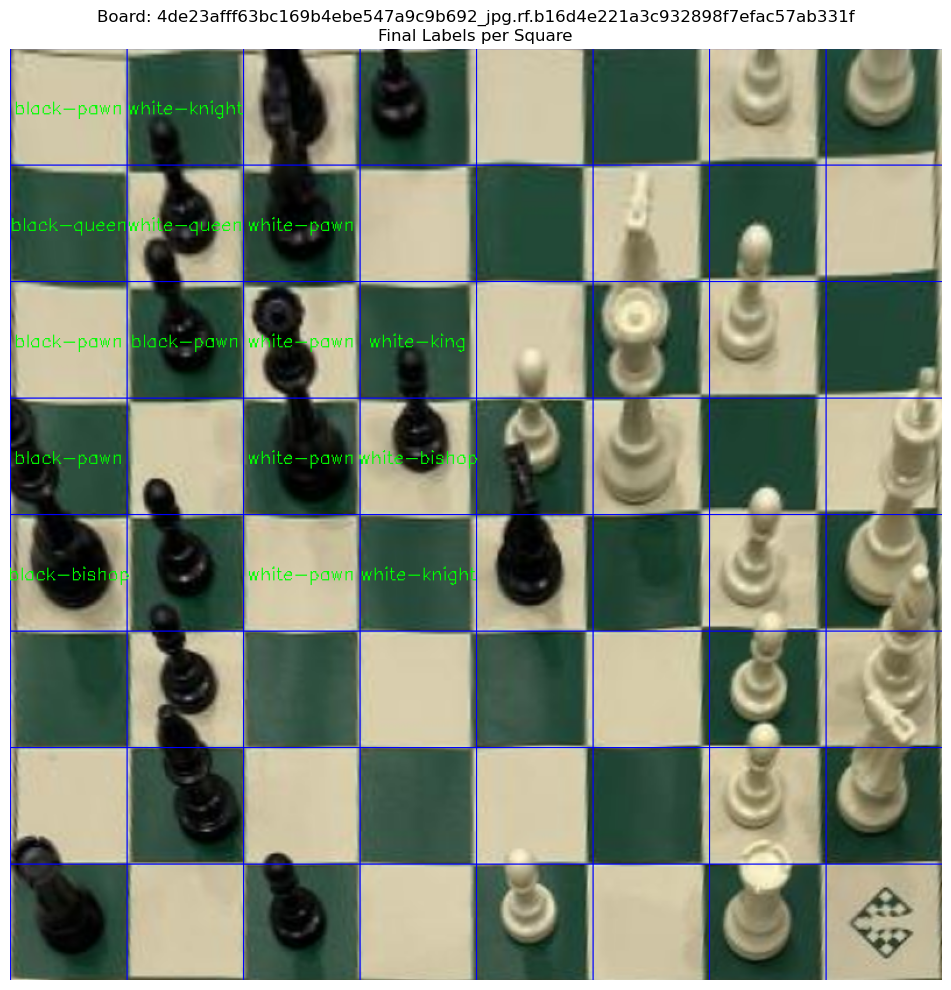

  ✓ Saved: 4de23afff63bc169b4ebe547a9c9b692_jpg.rf.958dc90b7cb5eeb2bdc66b0356537d03_points_grid.png


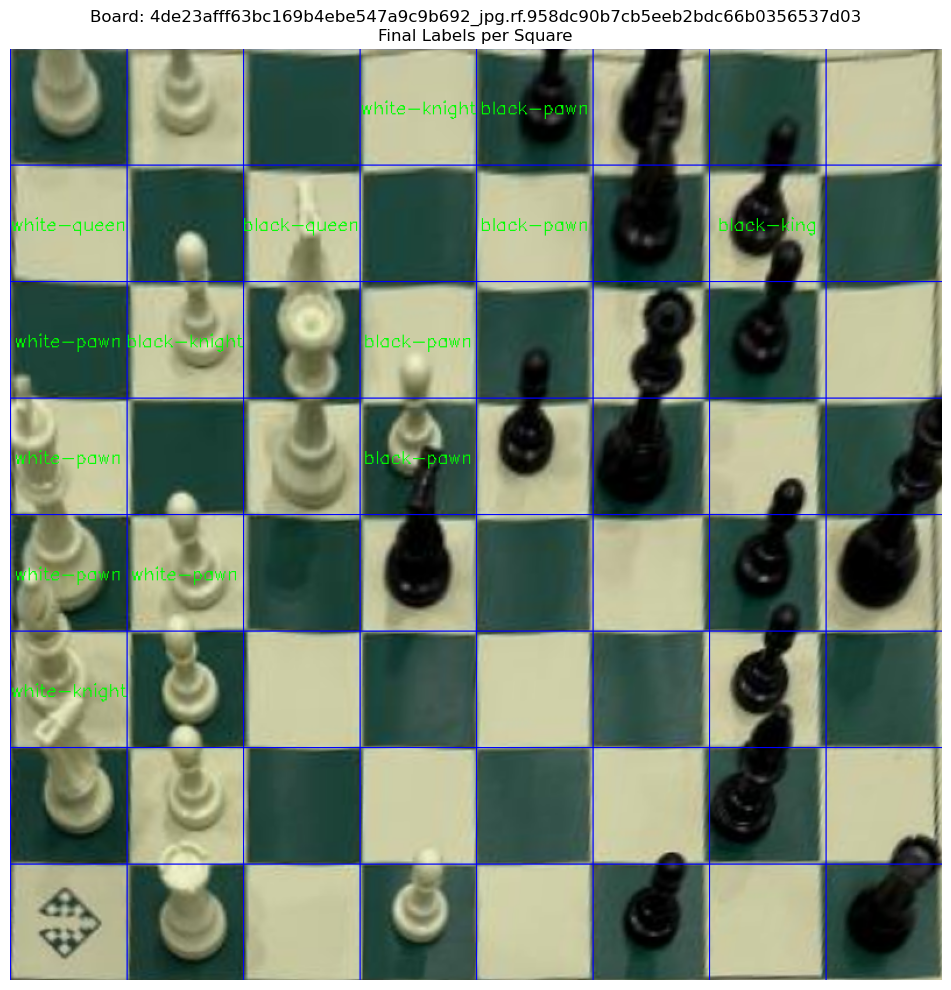

  ✓ Saved: 5e71cb8d41c333a18e799ef0004b040c_jpg.rf.3b081eddaeaa4d9e1da3f8990354d2b8_points_grid.png


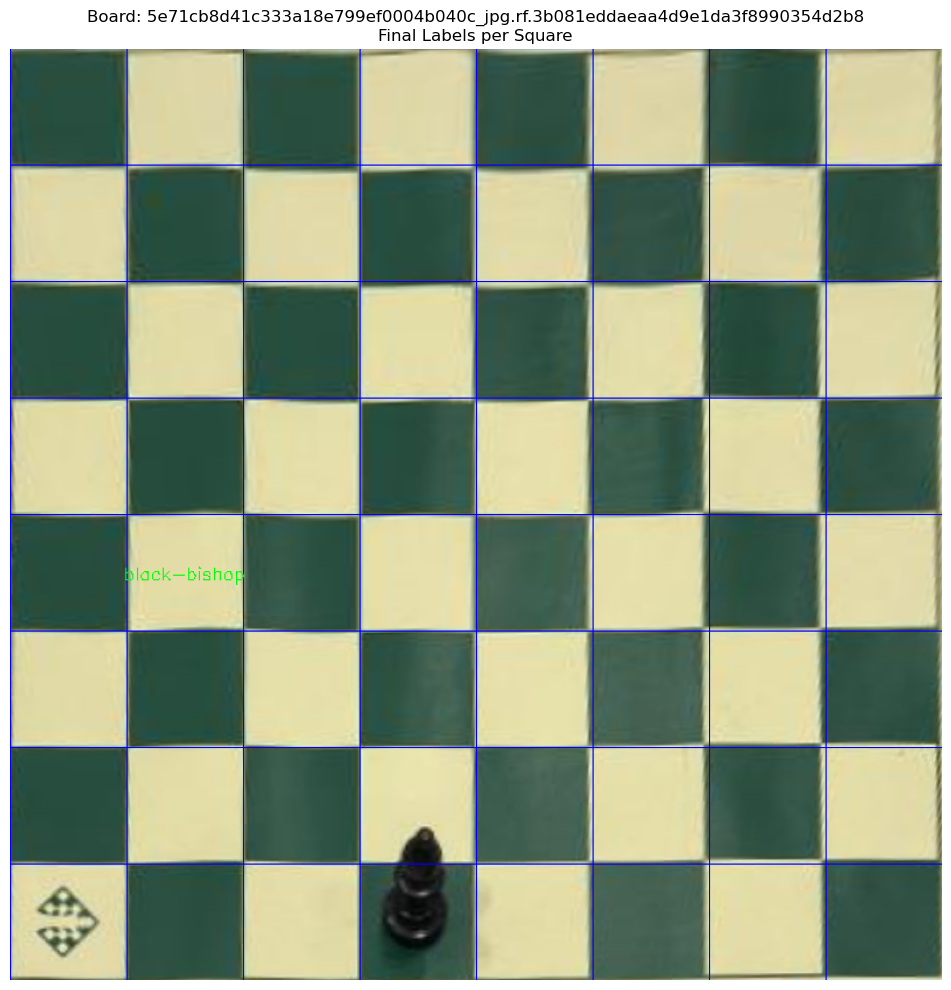


B) Creating square montage (4x4)...
  ✓ Saved: squares_montage_labeled.png


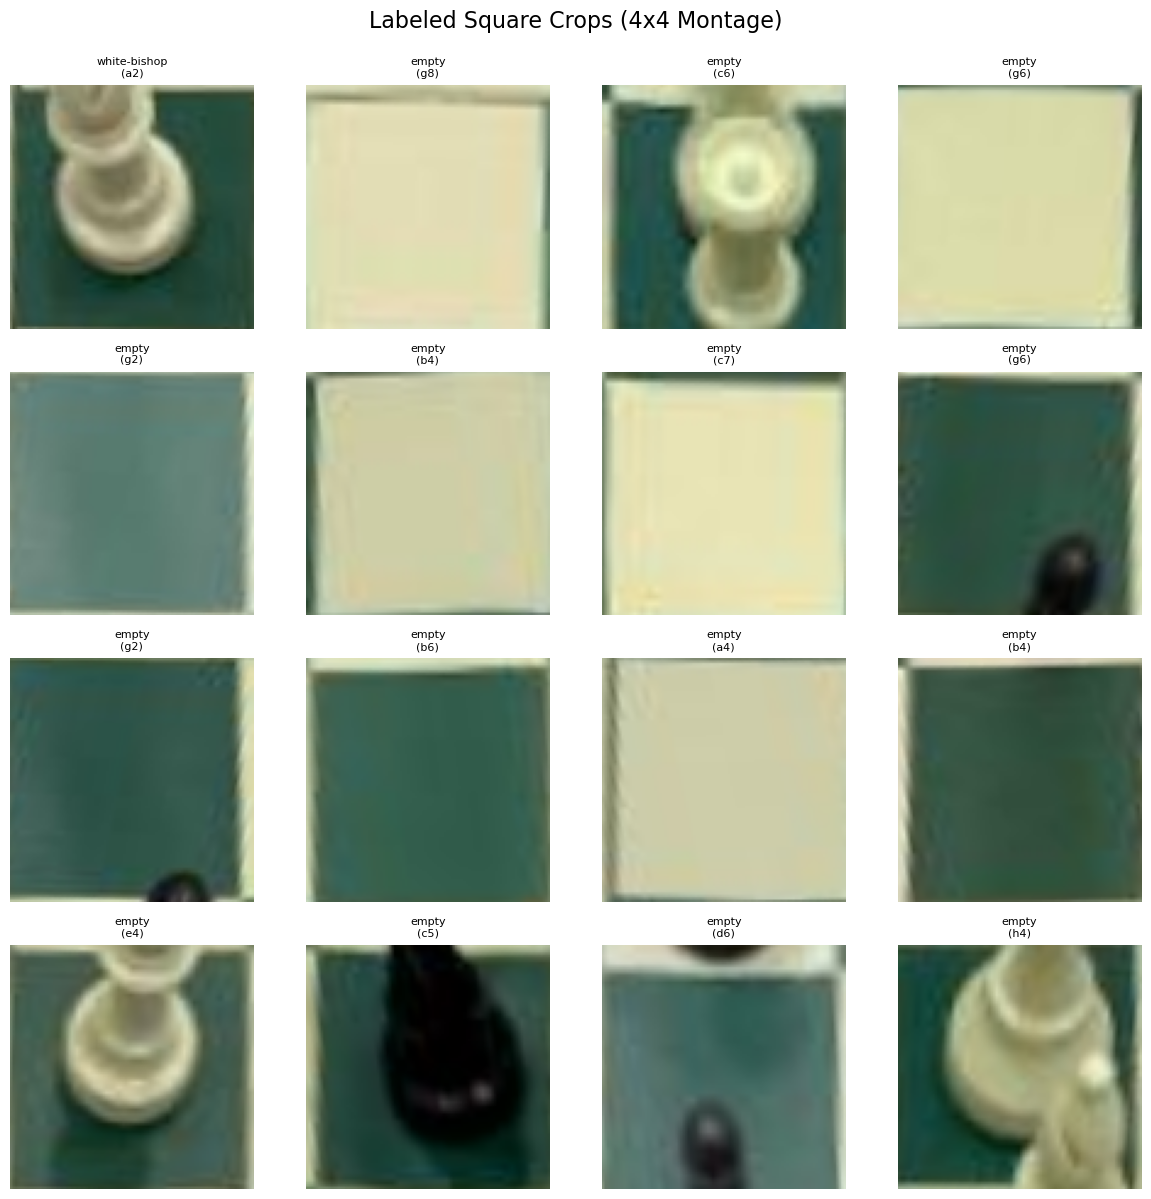


✓ Visual demo complete!


In [ ]:
# Visual Demo: Show bbox centers on warped boards and labeled square montage
print("="*80)
print("VISUAL DEMO: Board Points Grid + Square Montage")
print("="*80)

if train_labels_df is None:
    print("⚠️ Train labels not available. Please run Cell 13 first.")
else:
    import random

    # A) For 3 random boards: draw bbox polygons on warped board with grid
    warped_images_dir = WARPED_BASE / "train" / "images"
    debug_labeling_dir = PROJECT_ROOT / "data" / "processed" / "labels_boardcoords" / "train" / "debug"
    debug_labeling_dir.mkdir(parents=True, exist_ok=True)

    # Get unique board stems
    unique_boards = train_labels_df['board_stem'].unique()
    sample_boards = random.sample(list(unique_boards), min(3, len(unique_boards)))

    print(f"\nA) Creating board points grid visualizations for {len(sample_boards)} boards...")

    for board_stem in sample_boards:
        # Load warped board image
        warped_img_path = warped_images_dir / f"{board_stem}.png"
        if not warped_img_path.exists():
            print(f"  ⚠️ Warped image not found: {warped_img_path}")
            continue

        warped_bgr = cv2.imread(str(warped_img_path))
        if warped_bgr is None:
            print(f"  ⚠️ Failed to load image: {warped_img_path}")
            continue

        # Use BGR copy directly (fix COLOR_BGR2BGR bug)
        img_debug_bgr = warped_bgr.copy()

        # Load homography matrix
        M_path = warped_images_dir / f"{board_stem}_M.npy"
        if not M_path.exists():
            print(f"  ⚠️ Homography matrix not found: {M_path}")
            continue

        M = np.load(str(M_path))

        # Get bboxes for this board using EXACT stem matching
        bboxes_by_stem = yolo_data.get('train')
        if bboxes_by_stem is None:
            continue

        # Use EXACT stem matching (board_stem already has no extension, matches yolo key directly)
        bbox_list = bboxes_by_stem.get(board_stem, [])

        # Get square labels for this board to show predicted classes
        board_squares = train_labels_df[train_labels_df['board_stem'] == board_stem]
        square_labels_dict = {}
        for _, square_row in board_squares.iterrows():
            row = square_row['row']
            col = square_row['col']
            label = square_row['label_name']
            square_labels_dict[(row, col)] = label

        # Draw 8x8 grid
        for i in range(GRID_SIZE + 1):
            x = i * SQUARE_SIZE
            cv2.line(img_debug_bgr, (x, 0), (x, BOARD_SIZE), (255, 0, 0), 1)
            y = i * SQUARE_SIZE
            cv2.line(img_debug_bgr, (0, y), (BOARD_SIZE, y), (255, 0, 0), 1)

        # Draw final labels per square (max 64 texts) - only show winning labels, not all bboxes
        for row in range(GRID_SIZE):
            for col in range(GRID_SIZE):
                label_name = square_labels_dict.get((row, col), 'empty')
                if label_name != 'empty':
                    # Square center coordinates
                    cx = (col + 0.5) * SQUARE_SIZE
                    cy = (row + 0.5) * SQUARE_SIZE

                    # Draw label at square center
                    label_text = label_name
                    font_scale = 0.5
                    thickness = 1
                    (text_width, text_height), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
                    # Center the text
                    text_x = int(cx - text_width / 2)
                    text_y = int(cy + text_height / 2)
                    cv2.putText(img_debug_bgr, label_text, (text_x, text_y),
                               cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0, 255, 0), thickness)

        # Convert BGR to RGB for matplotlib (at the very end)
        img_debug_rgb = cv2.cvtColor(img_debug_bgr, cv2.COLOR_BGR2RGB)
        output_path = debug_labeling_dir / f"{board_stem}_points_grid.png"
        plt.imsave(output_path, img_debug_rgb)
        print(f"  ✓ Saved: {output_path.name}")

        # Display the image (with fresh figure)
        plt.figure(figsize=(10, 10))
        plt.imshow(img_debug_rgb)
        plt.title(f"Board: {board_stem}\nFinal Labels per Square", fontsize=12)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()  # Close figure to avoid accumulation

    # B) Montage: 16 square crops with labels
    print(f"\nB) Creating square montage (4x4)...")

    # Sample 16 random squares
    sample_size = min(16, len(train_labels_df))
    sample_df = train_labels_df.sample(n=sample_size, random_state=42)

    # Create 4x4 grid
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Labeled Square Crops (4x4 Montage)', fontsize=16, y=0.995)

    squares_images_dir = SQUARES_BASE / "train" / "images"

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        row_idx = idx // 4
        col_idx = idx % 4
        ax = axes[row_idx, col_idx]

        # Load square image
        square_filename = row['square_filename']
        square_path = squares_images_dir / square_filename

        if square_path.exists():
            square_img = cv2.imread(str(square_path))
            if square_img is not None:
                square_img_rgb = cv2.cvtColor(square_img, cv2.COLOR_BGR2RGB)
                ax.imshow(square_img_rgb)

        # Set title: label_name + chess_notation
        label_name = row['label_name']
        chess_notation = row.get('chess_notation', '')
        title = f"{label_name}"
        if chess_notation:
            title += f"\n({chess_notation})"
        ax.set_title(title, fontsize=8)
        ax.axis('off')

    plt.tight_layout()

    # Save montage
    montage_path = debug_labeling_dir / "squares_montage_labeled.png"
    plt.savefig(montage_path, dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {montage_path.name}")

    # Display the montage
    plt.show()
    plt.close('all')  # Close all figures to avoid accumulation

    print("\n" + "="*80)
    print("✓ Visual demo complete!")
    print("="*80)